<div style="background-color: #FFD700; padding: 20px; text-align: center; border-radius: 10px;">
    <h1 style="margin: 0; font-weight: bold;">
        <span style="color: red;">Malaria</span>
        <span style="color: #388E3C;"> Cell Image Classification with CNN</span>
    </h1>
</div>

Deep learning image classification of malaria cell images using a Convolutional Neural Network (CNN)

This project investigates binary image classification of malaria cell images using a Convolutional Neural Network (CNN). The dataset contains two classes: **Parasitized** and **Uninfected**, with approximately 27,558 cell images.

The workflow covers image loading, preprocessing, normalization, CNN model construction, training, validation, and model saving. The objective is to demonstrate a practical deep learning approach to medical image classification.

| Class / Item | Description |
| --- | --- |
| Parasitized | Cell images containing malaria parasites |
| Uninfected | Healthy cell images without malaria parasites |
| Total Images | Approximately 27,558 images |
| Task | Binary image classification |
| Data Source | NIH malaria cell image dataset / public mirrors such as Kaggle |


<img src="https://cdn.prod.website-files.com/5f4cddfc775065573435725c/65fab64330a568ce8b5ec5df_Malaria_Tropenkrankheit_Impfen_M%C3%BCcke.jpg" width="1000">
<a href='https://classroom.google.com/c/NzIwMjcyMjkxMjgy/a/NzIwMjc2NTM4NTIw/details' target=_blank>
Click here for the dataset </a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/malaria-dataset'

In [4]:
import os

# List the contents of the Google Drive root directory
os.listdir('/content/drive/MyDrive')

['Classroom', 'Colab Notebooks', 'Malaria', 'cell_images', 'malaria_data.csv']

In [5]:
file_path = '/content/drive/MyDrive/Malaria/cell_images/'

In [6]:
# Paths to the image folders in Google Drive
file_path_parasitized = '/content/drive/MyDrive/Malaria/cell_images/Parasitized/'
file_path_uninfected = '/content/drive/MyDrive/Malaria/cell_images/Uninfected/'


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

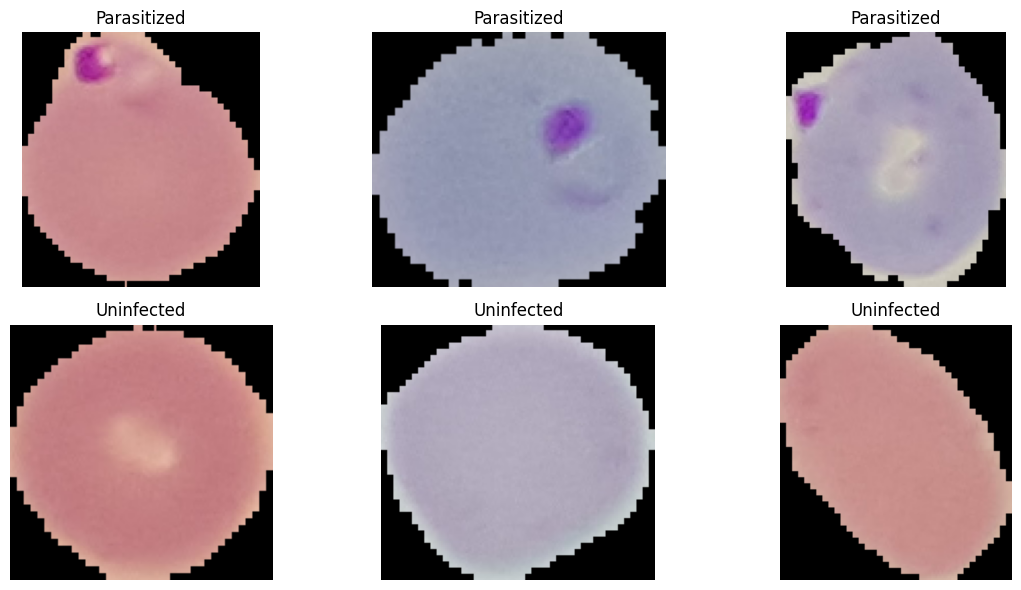

In [8]:
# List image files in both folders 
parasitized_images = os.listdir(file_path_parasitized)
uninfected_images = os.listdir(file_path_uninfected)

# Select 3 random images from each class
import random
random_parasitized = random.sample(parasitized_images, 3)  # 3 zufällige Bilder aus "Parasitized"
random_uninfected = random.sample(uninfected_images, 3)  # 3 zufällige Bilder aus "Uninfected"

# Create a 2x3 grid for visualization
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

## Display Parasitized images
for i, img_name in enumerate(random_parasitized):
    img = mpimg.imread(os.path.join(file_path_parasitized, img_name))
    axs[0, i].imshow(img)
    axs[0, i].axis('off')
    axs[0, i].set_title('Parasitized')

# Display Uninfected images
for i, img_name in enumerate(random_uninfected):
    img = mpimg.imread(os.path.join(file_path_uninfected, img_name))
    axs[1, i].imshow(img)
    axs[1, i].axis('off')
    axs[1, i].set_title('Uninfected')

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

In [10]:
# Initialize image path and label lists
img_list = []
label_list = []

In [11]:
# Read image paths from the Parasitized folder
for img_name in os.listdir(file_path_parasitized):
    img_list.append(os.path.join(file_path_parasitized, img_name))  
    label_list.append('Parasitized')  

# Read image paths from the Uninfected folder
for img_name in os.listdir(file_path_uninfected):
    img_list.append(os.path.join(file_path_uninfected, img_name))  
    label_list.append('Uninfected')  

In [12]:
#  Create a DataFrame containing image paths and labels
df = pd.DataFrame({'img': img_list, 'label': label_list})

# Inspect the loaded data
print(df.head())

# Encode class labels as numerical values
label_mapping = {'Parasitized': 0, 'Uninfected': 1}
df['encode_label'] = df['label'].map(label_mapping)

df.head()

                                                 img        label
0  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
1  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
2  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
3  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
4  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized


,img,label,encode_label
0,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
1,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
2,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
3,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
4,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0


In [13]:
df.to_csv('/content/drive/MyDrive/malaria_data.csv', index=False)

In [14]:
import cv2
import numpy as np

x = []  # List to store the images

# Process each file and keep the label only when the image is readable
for img_path in df['img']:
    
    img = cv2.imread(img_path)

    if img is not None:  
        img = cv2.resize(img, (32, 32))  
        img = img / 255.0  # Normalize pixel values
        x.append(img)  
    else:
        print(f"Warning: {img_path} konnte nicht gelesen werden.")  # Falls das Bild nicht geladen werden kann

# Convert the list into a NumPy array
x = np.array(x)

print("Shape von x:", x.shape)

Shape von x: (27564, 32, 32, 3)


In [24]:
x=np.array(x)
y=df['encode_label'].values

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [17]:
# Model architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # First convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling layer
model.add(Conv2D(64, (3, 3), activation='relu'))  # Second convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling layer
model.add(Flatten())  # Flattening the feature maps to 1D vector
model.add(Dense(128, activation='relu'))  # Fully connected layer with 128 units
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting
model.add(Dense(2, activation='softmax'))  # Output layer for 2 classes (binary classification)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Fit the model
history = model.fit(x, y, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.6931 - loss: 0.5792 - val_accuracy: 0.8727 - val_loss: 0.2788
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9176 - loss: 0.2084 - val_accuracy: 0.8937 - val_loss: 0.3132
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9448 - loss: 0.1570 - val_accuracy: 0.8908 - val_loss: 0.3165
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9524 - loss: 0.1384 - val_accuracy: 0.9637 - val_loss: 0.1403
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9552 - loss: 0.1296 - val_accuracy: 0.9298 - val_loss: 0.2274
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9570 - loss: 0.1176 - val_accuracy: 0.9452 - val_loss: 0.1906
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9587 - loss: 0.1201 - val_accuracy: 0.9588 - val_loss: 0.1525
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9640 - loss: 0.1060 - 

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 944,072 (3.60 MB)

 Trainable params: 314,690 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 629,382 (2.40 MB)

In [23]:
model.save('my_m_cnn_model.h5')

**Summary**

After 10 training epochs, the CNN reached a final training accuracy of **96.79%** with a training loss of **0.0899**. The final validation accuracy was **96.50%**, with a validation loss of **0.1195**.

These results show that a relatively compact CNN can learn useful visual patterns for distinguishing **Parasitized** and **Uninfected** cell images. The reported validation metrics come from the notebook's validation split and should be interpreted as project-level results rather than clinical performance.

> **Disclaimer:** This project is for educational and portfolio purposes only and is not intended for medical diagnosis.
